# 03. 일반화 오차 실험 (STS vs MTS vs FT)

- 테스트 시점들에서 tau_star별 out-of-sample reconstruction RMSE 비교 (논문 Figure 3)
- middle activation: linear vs tanh
- 압축률 C 실험 (논문 Phase 3)

`SMOKE = True` 이면 적은 grid / 적은 테스트 날짜로 빠르게 실행한다.
전체 재현 시에는 `SMOKE = False` 로 두고 실행한다 (수 시간 소요 가능).

In [1]:
# 공통 설정 (00_environment_check.ipynb 와 동일)
from pathlib import Path
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

ROOT = Path("..").resolve()
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
SAMPLE_DIR = DATA_DIR / "sample"
REPORT_DIR = ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
RESULT_DIR = REPORT_DIR / "results"
for p in [RAW_DIR, PROCESSED_DIR, SAMPLE_DIR, FIG_DIR, RESULT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


## Cell 1: 공통 함수 (02 노트북과 동일) + 데이터 로드

In [2]:
# 01_data_and_returns.ipynb 에서 저장한 processed 데이터 로드
with open(PROCESSED_DIR / "stock_panel.pkl", "rb") as fh:
    panel = pickle.load(fh)

prices = panel["prices"]
returns_by_tau = panel["returns_by_tau"]
norm_by_tau = panel["norm_by_tau"]
sigma_by_tau = panel["sigma_by_tau"]
TAU_MAX = max(returns_by_tau.keys())
dates = prices.index
print("assets:", prices.shape[1], "| days:", prices.shape[0], "| tau: 1..%d" % TAU_MAX)

assets: 100 | days: 3000 | tau: 1..20


In [3]:
LOOKBACK = 1200  # 논문: 타임스케일당 학습 샘플 수 고정


def build_train_positions(t_pos: int, tau: int, lookback: int = LOOKBACK) -> list:
    # t_train_tau(t) = { t-(tau-1)-1, ..., t-(tau-1)-lookback }
    # 현재 시점 수익률과 기간이 겹치는 최근 tau-1개 시점을 제외해 정보 누수를 방지
    end = t_pos - (tau - 1)          # exclusive
    start = end - lookback
    if start < tau:
        raise ValueError(f"t_pos={t_pos}, tau={tau}: 학습 구간이 데이터 범위를 벗어남")
    return list(range(start, end))


def valid_assets(norm_by_tau: dict, t_pos: int, tau_star: int, lookback: int = LOOKBACK) -> list:
    # 학습 구간 + 현재 시점 모두에서 결측이 없는 자산만 사용 (날짜별 investable universe)
    ok = None
    for tau in range(1, tau_star + 1):
        pos = build_train_positions(t_pos, tau, lookback) + [t_pos]
        good = norm_by_tau[tau].iloc[pos].notna().all(axis=0)
        ok = good if ok is None else (ok & good)
    return list(ok.index[ok])


def extract_matrix(norm_returns: pd.DataFrame, positions: list, assets: list) -> np.ndarray:
    X = norm_returns.iloc[positions][assets].to_numpy(dtype=np.float32)
    if np.isnan(X).any():
        raise ValueError("학습 행렬에 NaN 존재 - universe 처리 필요")
    return X


def build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # STS: tau = tau_star 만 사용
    pos = build_train_positions(t_pos, tau_star, lookback)
    return extract_matrix(norm_by_tau[tau_star], pos, assets)


def build_mts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # MTS: tau = 1..tau_star 전부 사용 -> 샘플 수 = lookback * tau_star
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star + 1)
    ]
    return np.vstack(mats)


def build_ft_datasets(t_pos, tau_star, norm_by_tau, assets, lookback=LOOKBACK):
    # FT: tau = 1..tau_star-1 로 pre-train 후 tau_star 로 fine-tune
    X_ft = build_sts_dataset(t_pos, tau_star, norm_by_tau, assets, lookback)
    if tau_star == 1:
        return None, X_ft
    mats = [
        extract_matrix(norm_by_tau[tau], build_train_positions(t_pos, tau, lookback), assets)
        for tau in range(1, tau_star)
    ]
    return np.vstack(mats), X_ft



class AutoEncoder(nn.Module):
    # Input(N) -> Dense(M, middle_activation) -> Dense(N, linear),  M = N * C
    def __init__(self, n_assets, compression_ratio=0.5, middle_activation="linear"):
        super().__init__()
        n_hidden = max(1, int(n_assets * compression_ratio))
        act = nn.Identity() if middle_activation == "linear" else nn.Tanh()
        self.encoder = nn.Sequential(nn.Linear(n_assets, n_hidden), act)
        self.decoder = nn.Linear(n_hidden, n_assets)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)



def train_autoencoder(X_train: np.ndarray, config: dict, model: nn.Module = None) -> nn.Module:
    device = config["device"]
    torch.manual_seed(config["seed"])
    if model is None:
        model = AutoEncoder(
            X_train.shape[1],
            config["compression_ratio"],
            config["middle_activation"],
        ).to(device)
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=config["lr"])
    loss_fn = nn.MSELoss()
    X = torch.tensor(X_train, dtype=torch.float32, device=device)
    n, bs = X.shape[0], config["batch_size"]
    gen = torch.Generator().manual_seed(config["seed"])
    for _ in range(config["epochs"]):
        perm = torch.randperm(n, generator=gen).to(device)
        for i in range(0, n, bs):
            xb = X[perm[i : i + bs]]
            opt.zero_grad()
            loss = loss_fn(model(xb), xb)
            loss.backward()
            opt.step()
    return model


def pretrain_and_finetune(X_pre, X_ft, config):
    if X_pre is None:
        return train_autoencoder(X_ft, config)
    model = train_autoencoder(X_pre, config)
    return train_autoencoder(X_ft, config, model=model)


def reconstruct(model: nn.Module, X: np.ndarray) -> np.ndarray:
    device = next(model.parameters()).device
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32, device=device))
    return out.cpu().numpy()


def compute_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

## Cell 2: 실험 설정

In [4]:
SMOKE = True

CONFIG_BASE = {
    "epochs": 30 if SMOKE else 50,
    "batch_size": 128,
    "lr": 1e-3,
    "compression_ratio": 0.5,
    "middle_activation": "linear",
    "seed": SEED,
    "device": DEVICE,
}

TAU_STAR_GRID = [1, 5, 10, 20] if SMOKE else [1, 2, 3, 5, 10, 15, 20]
ACTIVATIONS = ["linear", "tanh"]
N_TEST_DATES = 4 if SMOKE else 60

# 테스트 구간: 학습에 필요한 최소 시점 이후 ~ 백테스트 구간(마지막 450일) 이전
MIN_POS = LOOKBACK + 2 * TAU_MAX + 10
TEST_END = len(dates) - 450
test_positions = np.linspace(MIN_POS, TEST_END, N_TEST_DATES).astype(int).tolist()
print("테스트 시점:", [str(dates[p].date()) for p in test_positions])

테스트 시점: ['2014-10-20', '2016-06-16', '2018-02-13', '2019-10-14']


## Cell 3: STS / MTS / FT 학습 루프

In [5]:
import time

records = []
t_start = time.time()

for act in ACTIVATIONS:
    config = dict(CONFIG_BASE, middle_activation=act)
    for t_pos in test_positions:
        for tau_star in TAU_STAR_GRID:
            assets = valid_assets(norm_by_tau, t_pos, tau_star)
            x_test = norm_by_tau[tau_star].iloc[t_pos][assets].to_numpy(dtype=np.float32)[None, :]

            if tau_star == 1:
                # tau_star=1 이면 STS == MTS == FT
                model = train_autoencoder(build_sts_dataset(t_pos, 1, norm_by_tau, assets), config)
                rmse = compute_rmse(x_test, reconstruct(model, x_test))
                results = {"STS": rmse, "MTS": rmse, "FT": rmse}
            else:
                results = {}
                X_sts = build_sts_dataset(t_pos, tau_star, norm_by_tau, assets)
                m = train_autoencoder(X_sts, config)
                results["STS"] = compute_rmse(x_test, reconstruct(m, x_test))

                X_mts = build_mts_dataset(t_pos, tau_star, norm_by_tau, assets)
                m = train_autoencoder(X_mts, config)
                results["MTS"] = compute_rmse(x_test, reconstruct(m, x_test))

                X_pre, X_ft = build_ft_datasets(t_pos, tau_star, norm_by_tau, assets)
                m = pretrain_and_finetune(X_pre, X_ft, config)
                results["FT"] = compute_rmse(x_test, reconstruct(m, x_test))

            for method, rmse in results.items():
                records.append({
                    "activation": act,
                    "date": dates[t_pos].date().isoformat(),
                    "tau_star": tau_star,
                    "method": method,
                    "rmse": rmse,
                })
        print(f"[{act}] {dates[t_pos].date()} 완료 ({time.time() - t_start:.0f}s)", flush=True)

df_gen = pd.DataFrame(records)
print("총 소요:", round(time.time() - t_start), "s")

[linear] 2014-10-20 완료 (17s)


[linear] 2016-06-16 완료 (35s)


[linear] 2018-02-13 완료 (51s)


[linear] 2019-10-14 완료 (68s)


[tanh] 2014-10-20 완료 (86s)


[tanh] 2016-06-16 완료 (103s)


[tanh] 2018-02-13 완료 (121s)


[tanh] 2019-10-14 완료 (138s)


총 소요: 138 s


## Cell 4: tau_star별 RMSE 집계 및 저장

In [6]:
df_gen.to_csv(RESULT_DIR / "generalization_error.csv", index=False)

agg = df_gen.groupby(["activation", "method", "tau_star"])["rmse"].mean().reset_index()
pivot = agg.pivot_table(index="tau_star", columns=["activation", "method"], values="rmse")
pivot.round(4)

activation  linear                    tanh                
method          FT     MTS     STS      FT     MTS     STS
tau_star                                                  
1           0.6797  0.6797  0.6797  0.7459  0.7459  0.7459
5           0.6196  0.6115  0.6561  0.6385  0.6293  0.7167
10          0.6755  0.6443  0.7101  0.6668  0.6411  0.7567
20          0.6236  0.5713  0.7003  0.6133  0.5770  0.7699

## Cell 5: RMSE 비교 그래프 (논문 Figure 3 대응)

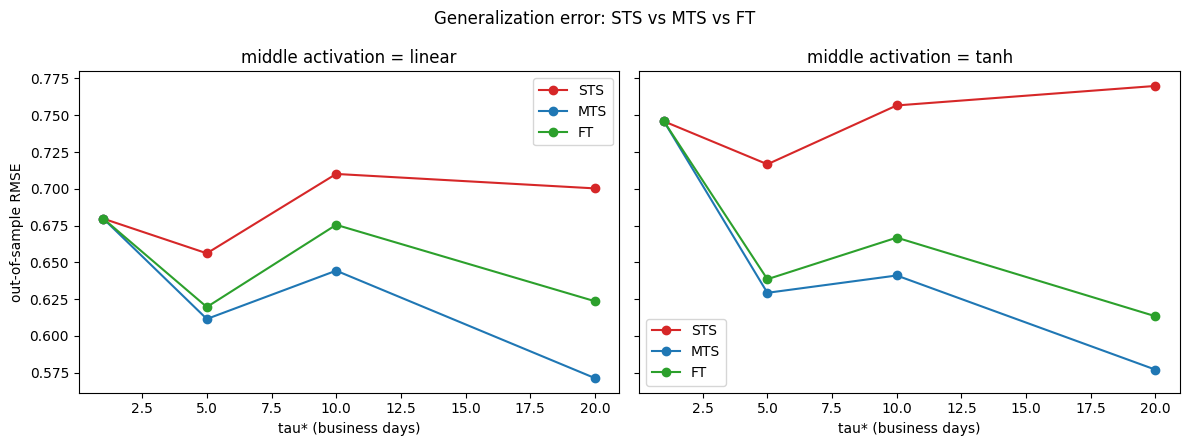

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
colors = {"STS": "tab:red", "MTS": "tab:blue", "FT": "tab:green"}
for ax, act in zip(axes, ACTIVATIONS):
    sub = agg[agg["activation"] == act]
    for method in ["STS", "MTS", "FT"]:
        s = sub[sub["method"] == method]
        ax.plot(s["tau_star"], s["rmse"], "o-", label=method, color=colors[method])
    ax.set_title(f"middle activation = {act}")
    ax.set_xlabel("tau* (business days)")
    ax.legend()
axes[0].set_ylabel("out-of-sample RMSE")
plt.suptitle("Generalization error: STS vs MTS vs FT")
plt.tight_layout()
plt.savefig(FIG_DIR / "generalization_error.png", dpi=120)
plt.show()

## Cell 6: 압축률(C) 실험 (Phase 3)

tau_star=20, MTS, linear 고정. C를 바꿔가며 out-of-sample RMSE 수렴 여부를 확인한다.
논문 결론: C ≈ 50% 부근에서 일반화 오차 수렴 → 이후 실험은 C=50% 사용.

In [8]:
C_GRID = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
comp_positions = test_positions[: (3 if SMOKE else len(test_positions))]

comp_records = []
for t_pos in comp_positions:
    assets = valid_assets(norm_by_tau, t_pos, 20)
    X_mts = build_mts_dataset(t_pos, 20, norm_by_tau, assets)
    x_test = norm_by_tau[20].iloc[t_pos][assets].to_numpy(dtype=np.float32)[None, :]
    for c in C_GRID:
        config = dict(CONFIG_BASE, compression_ratio=c)
        m = train_autoencoder(X_mts, config)
        comp_records.append({
            "date": dates[t_pos].date().isoformat(),
            "compression_ratio": c,
            "rmse": compute_rmse(x_test, reconstruct(m, x_test)),
        })
    print(f"{dates[t_pos].date()} 완료", flush=True)

df_comp = pd.DataFrame(comp_records)
df_comp.to_csv(RESULT_DIR / "compression_ratio.csv", index=False)

2014-10-20 완료


2016-06-16 완료


2018-02-13 완료


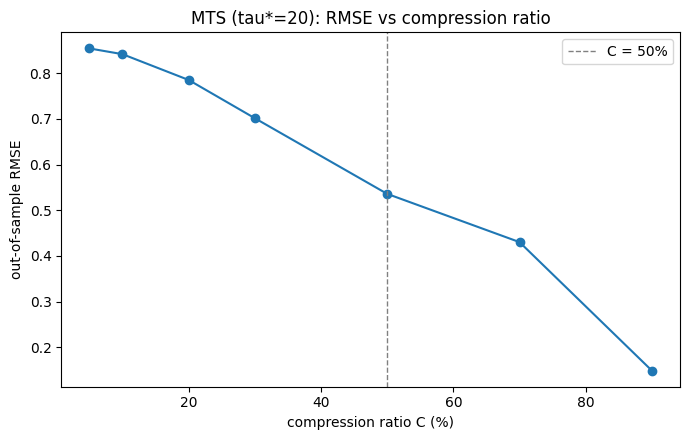

In [9]:
# Cell 7: 압축률 그래프
comp_agg = df_comp.groupby("compression_ratio")["rmse"].mean()
plt.figure(figsize=(7, 4.5))
plt.plot(comp_agg.index * 100, comp_agg.values, "o-")
plt.axvline(50, color="gray", ls="--", lw=1, label="C = 50%")
plt.xlabel("compression ratio C (%)")
plt.ylabel("out-of-sample RMSE")
plt.title("MTS (tau*=20): RMSE vs compression ratio")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "compression_ratio.png", dpi=120)
plt.show()